# Entraînement de modèles sur les grappes

Dans ce notebook, nous allons nous pencher sur deux façon d'entraîner des modèles sur les grappes de l'alliance:

- Sur Jupyter
- Avec une tâche batch

Dans les deux cas, le code d'entraînement sera sensiblement le même. Le focus restera justement sur quelles sont les differences, et ce qu'il faut savoir pour que tout fonctionne dans un cas comme dans l'autre.

## Entraîner un modèle sur Jupyter

Comme nous avons vu précédemment, un environnement Jupyer sur nos grappes n'est qu'une tâche interactive sur un noeud de calcul. La première étape est donc d'installer les paquets Python et charger les modules dont nous arons besoin.

Pour installer des paquets, il suffit d'utiliser la commande <code>pip install</code> **directement dans une cellule du notebook**. Notez l'absence d'un <code>!</code>. Le point d'éxclamation n'est pas seulement pas nécessaire, si vous l'ajoutez, l'installation des paquets aura lieu au mauvais endroit et vous aurez une erreur de type "not found" lorsque vous essayerez de les importer.

Pour notre exemple aujourd'hui, nous n'aurons besoin que de deux paquets: <code>torch</code> et <code>torchvision</code>

In [ ]:
pip install --no-index torch torchvision

Pour notre exemple d'entraînement, nous allons utiliser le tutoriel disponible sur [la documentation de l'Alliance sur PyTorch](https://docs.alliancecan.ca/wiki/PyTorch#Running_on_CPU). Il s'agit d'un réseau de neuronnes à convolutions que nous allons entraîner pour classifier des images du jeu de données CIFAR10: 

In [ ]:
import os

os.environ["OMP_NUM_THREADS"] = "2"

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

torch.set_default_device('cpu')
torch.set_num_threads(2)


class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()

        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001)

transform_train = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

dataset_train = CIFAR10(root='./data', train=True, download=False, transform=transform_train)

train_loader = DataLoader(dataset_train, batch_size=args.batch_size, num_workers=args.num_workers, pin_memory=True)

def train(model, n_iterations, data):

    for iteration in range(n_iterations):
        for batch_idx, (inputs, targets) in data:

            inputs = inputs
            targets = targets

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


In [ ]:
%timeit train(net,n_iterations=1, data=enumerate(train_loader))

### Estimer le temps d'exécution

Dans la cellule ci-haut, nous avons utilisé la **fonction magique** <code>%timeit</code>. Cette fonction exécute le code qui la suit un certain nombre de fois et calcule des statistiques sur le temps d'exécution. Ici, nous avons mesuré le temps d'exécution d'une boucle d'entraînement à une époque. C'est une bonne pratique d'utiliser un nombre réduit d'itérations pour estimer le temps total d'exécution. Sur Jupyter, ainsi que les tâches interactives en général, **il n'est pas recommendé** d'entraîner des modèles pendant des longues durées. Sur Jupyter, il y a une limite de temps qui varie delon la grappe, mais cette limite est en général très basse.

"Mais je dois garder un oeil sur des graphiques de performance pendant l'entraînement!"

Nous verrons plus tard dans l'atelier comment "s'attacher" à une tâche batch et observer des métriques d'entraînement dans une tâche de longue durée .

### Sauvegarder un modèle

Une fois un modèle entraîné, il ne reste qu'à le sauvegarder. Pour des tâches d'entraînement assez rapides pour que ce soit fait sur Jupyter, il suffit d'attendre la fin de la boucle et sauvegarder le modèle avec:

In [ ]:
torch.save(model.state_dict(), "./model.pt")

Vous pouvez charger ce modèle plus tard pour poursuivre l'entraînement ou pour faire des inférences:

In [ ]:
model = torch.load("./model.pt", weights_only=False)

## Entraîner un modèle avec une tâche batch

Imaginons qu'après avoir fait l'estimation de temps dans la section précedente, nous nous sommes rendus compte qu'entraîner notre réeseau de neuronnes à convolutions sur 10 époques prendrait beaucoup de temps, plus que que la limite permise sur Jupyter. Notre meilleure option devient alors de soumettre une tâche batch pour réaliser l'entraînement en mode non-interactif sur la grappe.

Il faut noter que la quantité de toutes les ressources sur Jupyter, non seulement le temps, est en général limitée sur nos grappes par rapport à la vraie quantité disponible sur les noeuds de calcul des grappes. Vous n'aurez donc pas accès à la quantité maximale disponible de mémoire vive, de coeurs CPU, ni de GPUs si vous utilisez Jupyter comme environnement où exécuter votre code d'entraînement. Faire le choix d'utiliser une tâche batch signifie donc que vous avez accès à plus de ressources, et que vous pouvez **possiblement atteindre un résultat final plus rapidement**. Nous verrons comment réflechir au sujet de la quantité de ressources demandée dans une prochaine section.

Pour entraîner le même modèle en mode batch, nous aurons besoin d'un script de tâche, et nous ferons quelques modifications au code Python de la section précedente pour qu'il soit exécutable dans le script de tâche.

### Le script de tâche

``` bash
#!/bin/bash
#SBATCH --nodes 1
#SBATCH --tasks-per-node=1 
#SBATCH --cpus-per-task=1 # change this parameter to 2,4,6,... to see the effect on performance

#SBATCH --mem=8G      
#SBATCH --time=0:05:00
#SBATCH --output=%N-%j.out
#SBATCH --account=<your account>

module load python # Using Default Python version - Make sure to choose a version that suits your application
virtualenv --no-download $SLURM_TMPDIR/env
source $SLURM_TMPDIR/env/bin/activate
pip install torch torchvision --no-index

export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

echo "starting training..."

python cifar10-cpu.py
```

### Le script Python

``` python
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

import argparse
import os

parser = argparse.ArgumentParser(description='cifar10 classification models, cpu performance test')
parser.add_argument('--lr', default=0.1, help='')
parser.add_argument('--batch_size', type=int, default=512, help='')
parser.add_argument('--num_workers', type=int, default=0, help='')

def main():

    args = parser.parse_args()
    torch.set_num_threads(int(os.environ['SLURM_CPUS_PER_TASK']))
    class Net(nn.Module):

       def __init__(self):
          super(Net, self).__init__()

          self.conv1 = nn.Conv2d(3, 6, 5)
          self.pool = nn.MaxPool2d(2, 2)
          self.conv2 = nn.Conv2d(6, 16, 5)
          self.fc1 = nn.Linear(16 * 5 * 5, 120)
          self.fc2 = nn.Linear(120, 84)
          self.fc3 = nn.Linear(84, 10)

       def forward(self, x):
          x = self.pool(F.relu(self.conv1(x)))
          x = self.pool(F.relu(self.conv2(x)))
          x = x.view(-1, 16 * 5 * 5)
          x = F.relu(self.fc1(x))
          x = F.relu(self.fc2(x))
          x = self.fc3(x)
          return x

    net = Net()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=args.lr)

    transform_train = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    dataset_train = CIFAR10(root='./data', train=True, download=False, transform=transform_train)

    train_loader = DataLoader(dataset_train, batch_size=args.batch_size, num_workers=args.num_workers)

    perf = []

    total_start = time.time()

    for batch_idx, (inputs, targets) in enumerate(train_loader):

       start = time.time()

       outputs = net(inputs)
       loss = criterion(outputs, targets)

       optimizer.zero_grad()
       loss.backward()
       optimizer.step()

       batch_time = time.time() - start

       images_per_sec = args.batch_size/batch_time

       perf.append(images_per_sec)

    total_time = time.time() - total_start
    
    print(f"Training time: {total_time}s")
    print(f"Training speed: {images_per_sec} images/s")

if __name__=='__main__':
   main()
```


Notez que le script, pour l'instant, ne demande que des CPU. L'entraînement se fait alors sur des coeurs CPU. Nous verrons comment et quand demander un GPU dans une prochaine section.

Notez aussi que nous avons ajouté une nouvelle mésure de performance ici - le nombre d'images traitées par seconde. Plus que le temps total d'exécution, cette mesure nous donne de l'information directe sur la capacité du hardware demandé à exécuter notre script. Nous pouvons faire des changements à notre script et mesurer l'impacte sur la performance de cette manière. Essayez de changer le nombre de CPUs.

## Monitorer l'entraînement avec MLFlow

Vous vous demandez peut-être pourquoi dans les exemples de cette section nous n'avons pas inclut des graphiques de métriques d'entraînement (loss, accuracy) comme nous l'avions fait dans le notebook sur le Deep Learning. En effet, garder un oeil sur l'evolution de ces métriques lors d'une tâche d'entraînement est crucial pour decider quand nous devons apporter des changements à un modèle, ou changer complètement de voie lorsqu'une combinaison de paramètres, ou une architecture de modèle ne semble pas très prometteur.

Or, nous avons omis ces graphiques ici car il y a une manière plus efficace de proceder que de les générer soi-même directement dans son code, comme nous l'avoins fait avant, et de les inspecter seulement une fois la tâche d'entraînement finie. Il est possible de monitorer ces graphiques **en temps réel**. C'est ce que nous verrons dans cette section: comment utiliser le paquet [MLFlow](https://docs.alliancecan.ca/wiki/MLflow) pour monitorer une tâche d'entraînement, qu'elle soit sur Jupyter ou dans une tâche batch!

Pour commencer nous allons installer le paquet en suivant les instructions indiquées sur la documentation. **Attention: il faut éteindre le Kernel de ce notebook avant de charger le module Arrow**, et ensuite le rallumer pour que le chargement prenne effet correctement.

Une fois, le module Arrow chargé, passons à l'installation. D'abord, nous allons installer deux paquets qui viennent avec le module Arrow directement dans notre environnement pour éviter des conflits lors de l'installation du paquet MLFlow:


In [ ]:
pip install --no-index packaging pandas --ignore-installed

En suite, nous installons le paquet MLFlow en tant que tel:

In [ ]:
pip install --no-index mlflow

Après avoir reinitialisé le kernel du Notebook pour que les installations prennent effet, nous pouvons passer à l'exemple pratique. Nous allons prendre le même code Pytorch que nous avons utilisé plus tôt dans cette section, et nous y ferons quelques modifications pour faire appel à MLFlow: 

In [ ]:
import os

os.environ["OMP_NUM_THREADS"] = "2"

import mlflow
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader


torch.set_default_device('cpu')
torch.set_num_threads(2)

# Même modèle que sur l'exemple anterieur

class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()

        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()

# première modification: dictionnaire de paramètres

params = {
    "epochs": 10,
    "learning_rate": 1e-3,
    "batch_size": 64,
}

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=params["learning_rate"])

transform_train = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

dataset_train = CIFAR10(root='./data', train=True, download=False, transform=transform_train)

train_loader = DataLoader(dataset_train, batch_size=params["batch_size"], num_workers=1, pin_memory=True)

# Dire à MLFlow de monitorer ce qui suit dans une "run"

with mlflow.start_run():

    mlflow.log_params(params)
    
    for iteration in range(params["epochs"]):
        
        # Nous allons monitorer le loss et l'accuracy à chaque époque
        
        train_loss = 0
        correct = 0
        total = 0
        
        for batch_idx, (inputs, targets) in enumerate(train_loader):

            inputs = inputs
            targets = targets

            outputs = net(inputs)
            loss = criterion(outputs, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        acc = 100 * correct / total
        avg_loss = train_loss / len(train_loader)
        
        # Sauvegarder le modèle directement avec MLFlow au lieu de torch.save()
        
        """model_info = mlflow.pytorch.log_model(
            pytorch_model=net,
            name=f"checkpoint-epoch-{iteration}",
            step=iteration
        )"""
        
        # Écrire les métriques que nous monitorons sur l'appli MLFlow
        
        mlflow.log_metrics(
            {"train_loss": avg_loss, "train_accuracy": acc},
            step=iteration,
            #model_id=model_info.model_id,  # Link metric to specific model
        )


Pendant que la tâche d'entraînement est en train d'être exécuté, ouvrez un onglet "launcher" et cliquez sur le button MLFlow. Un nouvel onglet s'ouvrira sur votre navigateur web avec l'appli MLFlow.

Sur MLFlow nous pouvons organiser nos tâches d'entraînement en "Experiments". Chaque tâche sur laquelle vous travaillez aura son propre Experiment, à l'interieur du quel vous pouvez avoir le nombre que vous voulez de "Runs", c'est à dire, d'essais! Vous pouvez ainsi garder un registre de ce que vous avez déjà essayé, ce qui a mieux marché, ce qui a moins bien marché... et ainsi de suite!

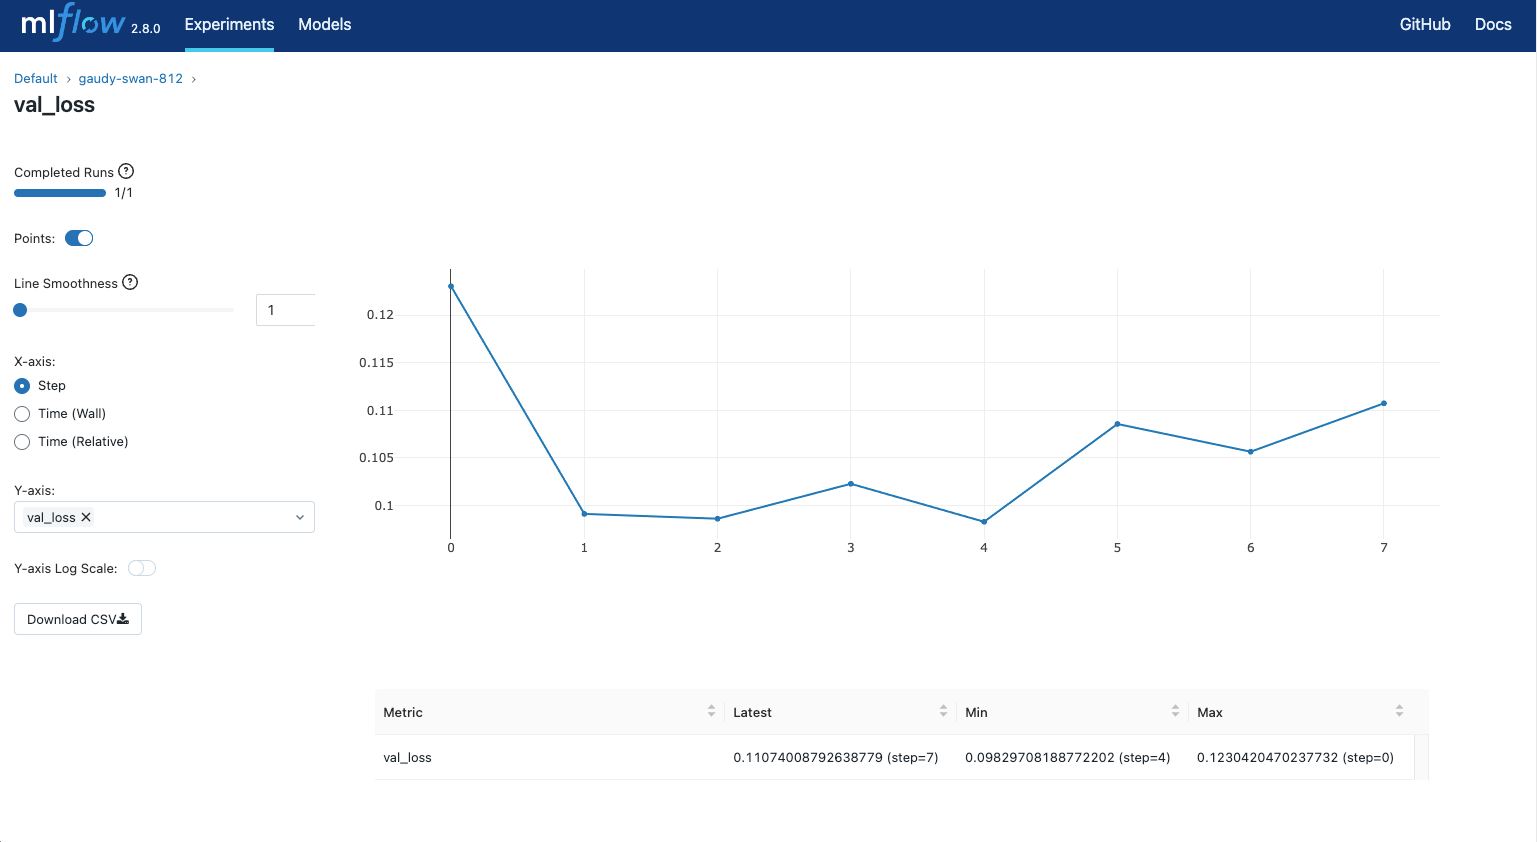